### Análisis a los accidentes ocurridos en Colombia
### Samuel Santiago Pinzón Reina

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Para los títulos y etiquetas de las gráficas se crea un diccionario con el estilo de fuente que se usará y se aplicará en el parámetro "fontdict"

font = {'family': 'serif',
        'color':  'darkred',
        'weight': 'normal',
        'size': 16,
        }

In [3]:
!wget -O datos.csv https://www.datos.gov.co/api/views/ha6j-pa2r/rows.csv?accessType=DOWNLOAD

--2025-05-01 05:20:52--  https://www.datos.gov.co/api/views/ha6j-pa2r/rows.csv?accessType=DOWNLOAD
Resolving www.datos.gov.co (www.datos.gov.co)... 52.206.68.26, 52.206.140.199, 52.206.140.205
Connecting to www.datos.gov.co (www.datos.gov.co)|52.206.68.26|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/csv]
Saving to: ‘datos.csv’

datos.csv               [        <=>         ]  10.52M  6.50MB/s    in 1.6s    

2025-05-01 05:20:54 (6.50 MB/s) - ‘datos.csv’ saved [11031933]



In [4]:
accidentes = pd.read_csv("datos.csv", sep= ",")

In [5]:
accidentes.shape

(84294, 9)

# **1. En qué departamentos se concentra la mayor cantidad de accidentes fatales?**

Para dar respuesta a esta pregunta lo que haremos será sumar la cantidad de apariciones de los departamentos en el dataframe y así obtendremos la cantidad de accidentes ocurridos

In [6]:
#Nuevo dataframe "accidentes_departamento" donde hacemos lo mencionado anteriormente
accidentes_departamento = accidentes['DEPARTAMENTO'].value_counts()
accidentes_departamento = pd.DataFrame(accidentes_departamento)
accidentes_departamento.columns = ["Cantidad total"]

accidentes_departamento.head()


,Cantidad total
DEPARTAMENTO,
CUNDINAMARCA,12282
ANTIOQUIA,11354
VALLE,9459
SANTANDER,4248
CESAR,3414


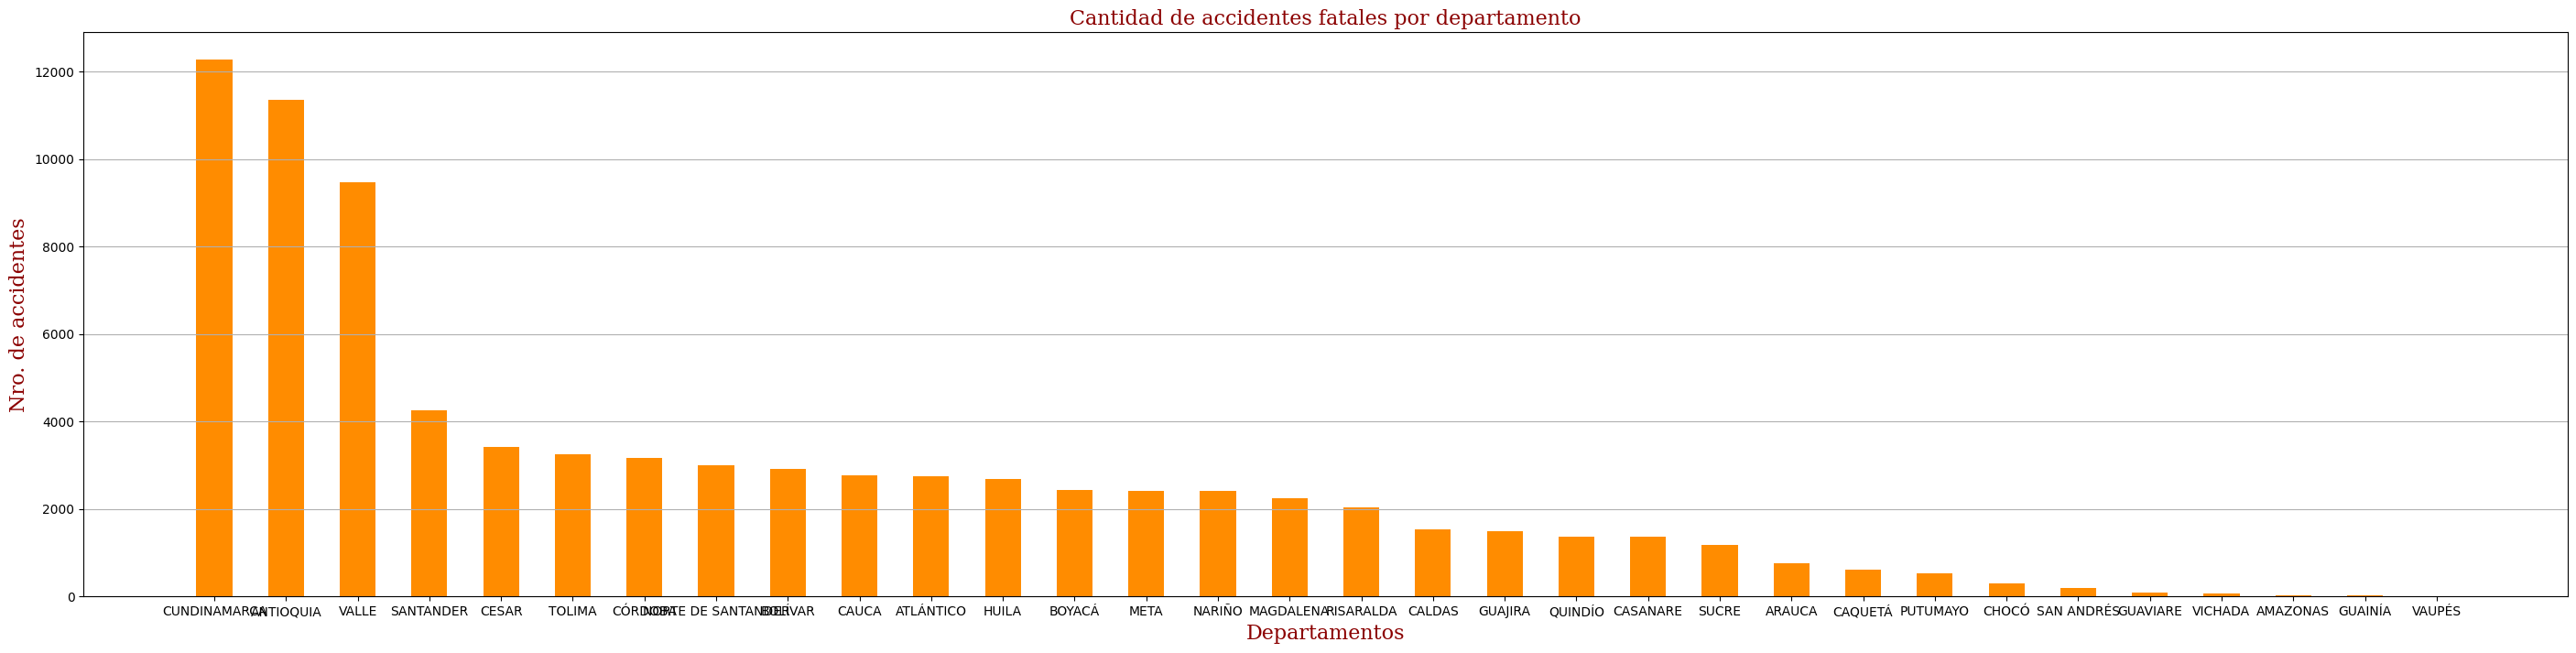

In [7]:
#Gráfico de barras con todos los accidentes ocurridos en todos los departamentos, pero necesitamos datos más específicos.

plt.figure(figsize = (35,8))

plt.bar(accidentes_departamento.index, accidentes_departamento["Cantidad total"], width = 0.5, color = "DarkOrange")

plt.title("Cantidad de accidentes fatales por departamento", fontdict= font)
plt.xlabel("Departamentos", fontdict= font)
plt.ylabel("Nro. de accidentes", fontdict= font)
plt.grid(axis = "y")

plt.show()

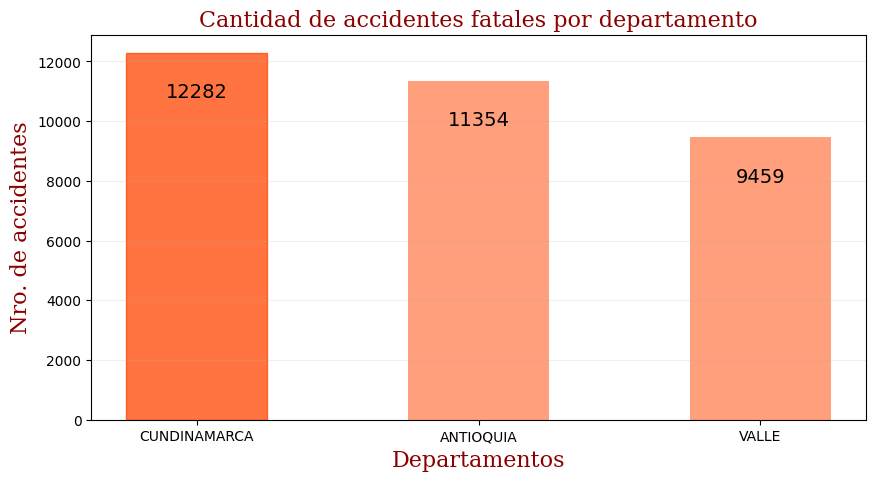

In [9]:
#Gráfico de los 3 municipios de Colombia con más accidentes fatales, los cuales son los lugares que más accidentes reportan en comparación a los otros departamentos.

plt.figure(figsize = (10,5))

barras = plt.bar(accidentes_departamento[:3].index, accidentes_departamento["Cantidad total"][:3], width = 0.5, color = "Coral", alpha = 0.75)

barras[0].set_color("OrangeRed")

for barra in barras:
  altura = barra.get_height()
  x = barra.get_x() + barra.get_width()/2
  plt.gca().text(x, altura - 1500, f"{altura}", ha = "center", fontsize = 14)

plt.title("Cantidad de accidentes fatales por departamento", fontdict= font)
plt.xlabel("Departamentos", fontdict= font)
plt.ylabel("Nro. de accidentes", fontdict= font)
plt.grid(axis = "y", alpha = 0.2)

plt.show()

## **Respuesta:**

Cómo pudimos ver en las dos gráficas anteriores los departamentos que más accidentes fatales reportan son los departamentos de **Cundinamarca, Antioquía y el Valle del Cauca.**

De esas gráficas también pudimos ver que muchos municipios presentan una cantidad de reportes similares entre sí, y que Santander es el que presenta una mayor diferencia frente a la gran mayoría de departamentos.

# **2. ¿En qué municipios se concentra la mayor cantidad de accidentes fatales?**

Para dar respuesta a esta pregunta podremos aplicar una metodología igual a la del primer punto, ya que nos piden lo mismo, con la diferencia que la cantidad de elementos es mucho mayor.

In [11]:
accidentes_municipios = accidentes['MUNICIPIO'].value_counts()
accidentes_municipios = pd.DataFrame(accidentes_municipios)
accidentes_municipios.columns = ["Cantidad total"]

accidentes_municipios.head()


,Cantidad total
MUNICIPIO,
BOGOTÁ D.C. (CT),5146
CALI (CT),3017
MEDELLÍN (CT),2862
Bogotá D.C. (CT),1284
Medellín (CT),968


Como podemos ver, nos muestra repetidas las ciudades de Bogotá y Medellín, ya que unas están en mayúscula y otras en minúscula. Por lo que haremos el cambio para que todos estén escritos de la misma forma:

In [23]:
#Como los municipios están como índices vamos a tomarlos y aplicarles el método para que todos inicien con la primera letra en mayúscula.
accidentes_municipios.index = accidentes_municipios.index.str.capitalize()

#Debido a que pueden haber repetidos, los vamos a agrupar para que nos muestre el valor total de estos municipios que se repiten.
accidentes_municipios = accidentes_municipios.groupby(accidentes_municipios.index).sum()

In [28]:
accidentes_municipios.sort_values(by = "Cantidad total", ascending = False, inplace = True)
accidentes_municipios.head()

,Cantidad total
MUNICIPIO,
Bogotá d.c. (ct),6430
Medellín (ct),3830
Cali (ct),3493
Cartagena (ct),1238
Barranquilla (ct),1205


Debido a que en Colombia hay una gran cantidad de municipios obtener los datos de cada municipio haría que se vieran muchos datos lo cual no respondería a la pregunta, por lo que procederemos a graficar las primera 5 ciudades que más cantidad de accidentes presentan:

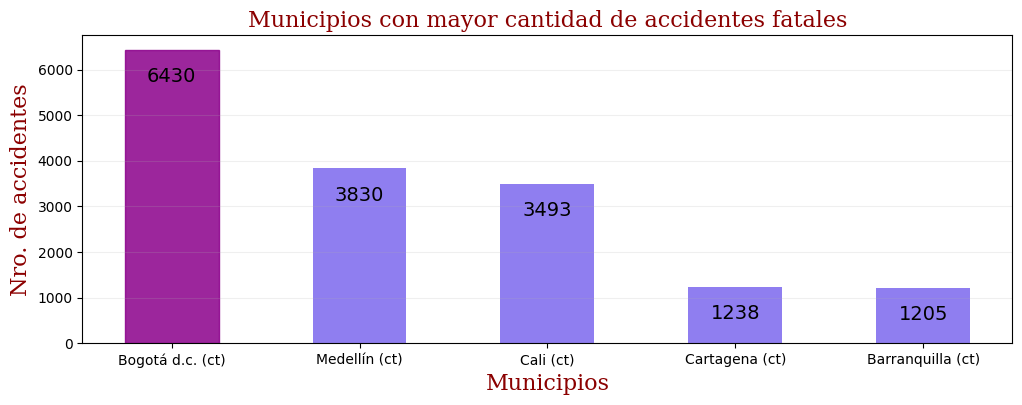

In [27]:
#Gráfico de los 5 municipios de Colombia con más accidentes fatales.

plt.figure(figsize = (12,4))

barras = plt.bar(accidentes_municipios[:5].index, accidentes_municipios["Cantidad total"][:5], width = 0.5, color = "MediumSlateBlue", alpha = 0.85)

barras[0].set_color("DarkMagenta")

for barra in barras:
  altura = barra.get_height()
  x = barra.get_x() + barra.get_width()/2
  plt.gca().text(x, altura - 700, f"{altura}", ha = "center", fontsize = 14)

plt.grid(axis = "y", alpha = 0.2)
plt.title("Municipios con mayor cantidad de accidentes fatales", fontdict= font)
plt.xlabel("Municipios", fontdict= font)
plt.ylabel("Nro. de accidentes", fontdict= font)

plt.show()

### **Respuesta:**

Como podemos ver en la gráfica, los cinco municipios que presentan mayor incidencia de accidentes fatales son las ciudades de **Bogotá, Medellín, Cali, Cartagena y Barranquilla**, las cuales hacen parte de los principales municipios del país y también de las ciudades capitales de los departamentos.

Importante resaltar la diferencia abismal entre la cantidad de accidentes de **Bogotá** con la de **Medellín**, ya que es casi como si duplicara el número de incidentes en la capital antioqueña. Lo que se explicaría con la gran cantidad de población que tiene la ciudad capitalina del país, ya que tiene mucha más población, en comparación al segundo, tercer, cuarto y quinto puesto.

# **3.¿En qué meses del año se observa mayor incidencia de accidentes fatales?**

Hallar la respuesta de esta pregunta será un poco más dificil que las anteriores, puesto que lo que toca hacer es separar la fecha del incidente que nos dan y separarla en tres columnas nuevas: AÑO, MES, DÍA.

Esto se hace con el fin de poder separar los datos unicamente por mes y así poder agrupar la cantidad de accidentes que han ocurrido en cada mes desde que se tiene registro.
Finalmente, una vez que tengamos la suma de la agrupación y los meses separados, se ordenan de manera descendente para ver los meses donde más ocurren este tipo de accidentes, y se grafica.

In [29]:
#Dividir el dataset con el delimitador "slash". n vale 3 porque vamos a separar en 3 los valores del str que representan la fecha en formato DD/MM/AA
separado = accidentes["FECHA HECHO"].str.split("/", n=3, expand=True)

#Se crea la columna día y se le asigna el primer elemento. Y así sucesivamente con el mes y el año
accidentes["DIA"]= separado[0]
accidentes["MES"]= separado[1]
accidentes["AÑO"] = separado[2]

In [30]:
accidentes.head()

,DEPARTAMENTO,MUNICIPIO,CODIGO DANE,ARMAS MEDIOS,FECHA HECHO,GENERO,GRUPO ETARÍO,DESCRIPCIÓN CONDUCTA,CANTIDAD,DIA,MES,AÑO
0,ANTIOQUIA,LA CEJA,5376000.0,MOTO,1/01/2010,MASCULINO,ADULTOS,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1,01,2010
1,ATLÁNTICO,BARRANQUILLA (CT),8001000.0,MOTO,1/01/2010,FEMENINO,ADULTOS,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1,01,2010
2,ATLÁNTICO,LURUACO,8421000.0,MOTO,1/01/2010,MASCULINO,ADULTOS,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1,01,2010
3,CAQUETÁ,PUERTO RICO,18592000.0,MOTO,1/01/2010,MASCULINO,ADOLESCENTES,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1,01,2010
4,CASANARE,AGUAZUL,85010000.0,MOTO,1/01/2010,MASCULINO,ADULTOS,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1,01,2010


In [31]:
#Agrupamos por meses  cantidad, así podemos obtener la suma de los accidentes que han ocurrido en todos los meses.
#Se ordena de manera descendente con fines de graficación.

agrupacion_meses = accidentes[["MES"]].value_counts()
agrupacion_meses

,count
MES,
01,8204
03,7507
02,7045
07,7045
04,6906
06,6834
10,6831
12,6723
05,6595


In [32]:
#Como vemos en "agrupacion_meses" estpan agrupados por meses del 1 al 12, por lo que obtenemos esos indices para cambiarlos por el nombre de los meses.

meses_list = list(agrupacion_meses.keys())
meses_list

[('01',),
 ('03',),
 ('02',),
 ('07',),
 ('04',),
 ('06',),
 ('10',),
 ('12',),
 ('05',),
 ('09',),
 ('08',),
 ('11',)]

In [33]:
#Debido a que los meses están en formato númerico creamos un diccionario con el nombre que le responde a cada número.
#Se hace con fines de obtener los datos de mejor manera para la graficación.

meses_dict = {('01',): "Enero",
              ("02",): "Febrero",
              ("03",): "Marzo",
              ("04",):"Abril",
              ("05",): "Mayo",
              ("06",): "Junio",
              ("07",): "Julio",
              ("08",): "Agosto",
              ("09",): "Septiembre",
              ("10",): "Octubre",
              ("11",): "Noviembre",
              ("12",): "Diciembre"}

In [34]:
#Iteramos por cada elemento de la lista de meses y obtenemos el nombre del mes a partir de la busqueda del nombre en el diccionario que hicimos.

for i in range(len(meses_list)):
    meses_list[i] = meses_dict.get(meses_list[i])

meses_list

['Enero',
 'Marzo',
 'Febrero',
 'Julio',
 'Abril',
 'Junio',
 'Octubre',
 'Diciembre',
 'Mayo',
 'Septiembre',
 'Agosto',
 'Noviembre']

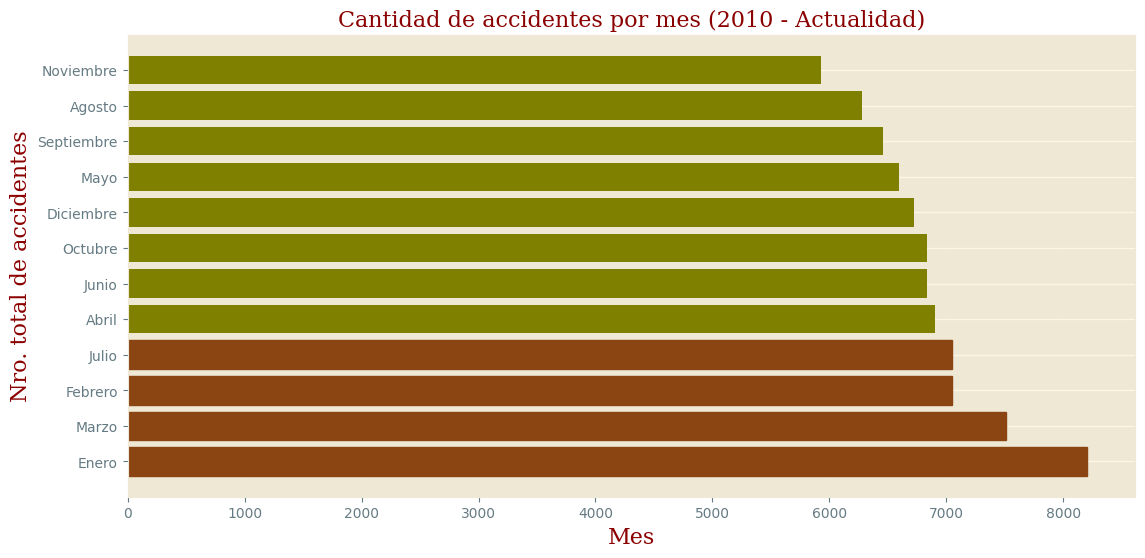

In [40]:
#Creamos la gráfica

plt.figure(figsize = (13,6))

with plt.style.context('Solarize_Light2'):

    barras_mes = plt.barh(meses_list, agrupacion_meses, color = "Olive")

    for barra in barras_mes:
      anchura = barra.get_width()
      if anchura > 7000:
        barra.set_color(c = "SaddleBrown") # resaltamos los meses que han tenido más de 7000 accidentes



    plt.title("Cantidad de accidentes por mes (2010 - Actualidad)", fontdict=font)
    plt.xlabel("Mes", fontdict=font)
    plt.ylabel("Nro. total de accidentes", fontdict=font)
    plt.grid(axis  = "x", alpha = 0.1)

plt.show()

##**Respuesta:**

Para saber qué meses son los más accidentados tomaremos a los que han tenido más de 7.000 accidentes, así que con esta condición podremos ver en los resultados de los gráficos que los meses con mas acontecimientos de accidentes son los meses de **Enero, Marzo, Febrero y Julio**.

Con lo cual podríamos relacionar con el contexto social de estas épocas, ya que los meses de **enero y febrero son los más accidentados** debido a que al ser épocas de vacaciones, habrá más gente que sale a pueblos, fincas, entre otros, y al  aumentar el número de conductores en la vía, aumenta el riesgo de accidentes.

Y pasa algo similar, para **julio**, el cual es el mes de vacaciones de mitad de año para colegios y universidades, lo que cause que muchas familias y amigos salgan, provocando lo mismo que en los primeros meses del año, que al haber más conductores en las carreteras, más accidentes habrán.

Del mes de **marzo** podemos decir que han habido muchos accidentes debido al clima del momento, debido a que marzo se caracteriza por ser un mes lluvioso, lo cual causa que hayan más probabilidad de accidentes.


# **4.¿Cómo ha variado la tasa de accidentes fatales en el tiempo?**

Similar al punto pasado, haremos una agrupación de la cantidad de accidentes habidos, pero esta vez lo haremos por años, y una vez tengamos esa agrupación y suma, graficaremos para ver cuantos accidentes han habido a lo largo de los años y ver qué tanto ha variado.

In [41]:
#Agrupamos por años y cantidad, así podemos obtener la suma de los accidentes que han ocurrido en cada año.

agrupacion_años = accidentes[["AÑO", "CANTIDAD"]].groupby(["AÑO"])["CANTIDAD"].sum()
agrupacion_años

,CANTIDAD
AÑO,
2010,4500.0
2011,4295.0
2012,4549.0
2013,4922.0
2014,4835.0
2015,5344.0
2016,5609.0
2017,5261.0
2018,6017.0


In [42]:
años = list(agrupacion_años.keys())
print(años)

['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


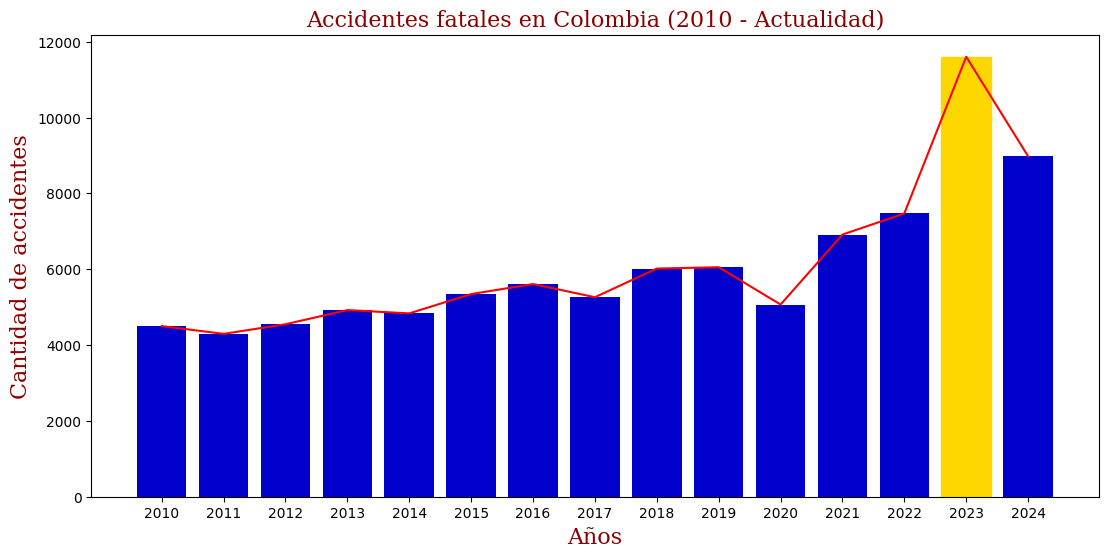

In [43]:
fig = plt.figure(figsize = (13,6))

with plt.style.context("fast"):
    barras_años = plt.bar(años, agrupacion_años, color = "MediumBlue")
    plt.plot(agrupacion_años, color = "Red", linestyle ="solid")


    max_altura = 0
    for barras in barras_años:
      if barras.get_height() > max_altura:
        max_altura = barras.get_height()
        barra_resaltar = barras

    barra_resaltar.set_color("Gold")


    plt.title("Accidentes fatales en Colombia (2010 - Actualidad)", fontdict = font)
    plt.xlabel("Años", fontdict = font)
    plt.ylabel("Cantidad de accidentes", fontdict = font)

plt.show()

## **Respuesta:**

En esta gráfica donde tenemos la cantidad de accidentes por año podemos ver el comportamiento que ha tenido, y graficandola mediante gráfico de barras y de lineas podemos observar aún mejor el comportamiento, y es que desde el 2010 hasta el año 2012 los accidentes se mantuvieron casi que constantes, pero a partir del 2013 empezamos a ver un patrón cada tres años, el cual consiste en que hay crecimiento, un ligero decrecimiento y, otra vez, un crecimiento, patrón en el que poco a poco van aumentando la cantidad deaccidentes. Pero que se rompé en el año 2023, porque en teoría este año debía ser de decrecimiento, pero por lo que vemos, es el año en el que más accidentes hubieron. Y de seguir con este patrón o uno nuevo todo indica que este año 2024 la cantidad de accidentes va a aumentar o rondar por los valores obtenidos en 2023.

# **5. ¿En qué día de la semana se presenta mayor riesgo de accidentes fatales?**

Responder esta pregunta presenta un poco más de dificultad, puesto que hay que conseguir los días de la semana en la que ocurrieron los accidentes, para ello primero crearemos el dataframe _dt_, y mediante iteraciones y uso del método _.day_name()_ obtendremos el día de la semana en esas fechas.

Luego calcularemos la cantidad de veces que se repiten los valores de los días de la semana, datso que usaremos para la gráfica. Pero antes de hacer todo esto para obtener los nombres de ldía de la semana en español haremos uso de un diccionario para intercambiar los nombres de los dias de la semana de inglés a español, y los añadiremos a una lista para así tener los labels para la gráfica de barras.


In [66]:
#Nuevo dataframe dt, el cual convierte en formato datetime las fechas de la columna de "FECHA HECHO"
dt = pd.to_datetime(accidentes['FECHA HECHO'], format="%d/%M/%Y")
dt = pd.DataFrame(dt)

dias = []

#Iteramos sobre el indice y contenido de la fila de dt para así obtener el día de la semana y agregarlo a la lista dias.
for index, row in dt.iterrows():
  dias.append(row["FECHA HECHO"].day_name())

In [68]:
#Comprobación de que sea la misma cantidad de datos que el dataset original. Lo que nos da a entender que cada fecha ha obtenido el nombre del día de la semana.
len(dias)

84294

In [69]:
#Para poder hacer uso de los métodos de pandas convertimos a "dias" en un dataframe
dias = pd.DataFrame(dias)
dias.head()

,0
0,Friday
1,Friday
2,Friday
3,Friday
4,Friday


In [70]:
#Como vemos el nombre de la columna es "0", por lo que para mejor entendimiento y organización renombramos la columna con "Día de la Semana"
dias.rename(columns = {0: "Día de Semana"}, inplace=True)
dias.head()

,Día de Semana
0,Friday
1,Friday
2,Friday
3,Friday
4,Friday


In [71]:
#Hacemos el recuento de las apariciones de los días de la semana
dias = dias.value_counts()
dias

,count
Día de Semana,
Sunday,12338
Monday,12237
Thursday,11829
Tuesday,11772
Wednesday,11767
Saturday,11280
Friday,11131


In [72]:
#Obtenemos y almacenamos los nombres de los días de la semana bajo la forma en la que aparecen en el dataframe
dias_lista = list(dias.keys())
dias_lista

[('Sunday',),
 ('Monday',),
 ('Thursday',),
 ('Tuesday',),
 ('Wednesday',),
 ('Saturday',),
 ('Friday',)]

In [73]:
#Almacenamos la cantidad de accidentes por día
suma_dias = dias.to_list()
suma_dias

[12338, 12237, 11829, 11772, 11767, 11280, 11131]

In [74]:
#Se crea el diccionario para traducir los días de la semana a español

dias_dict = {('Sunday',): "Domingo",
             ("Saturday",): "Sábado",
             ('Friday',): "Viernes",
             ("Monday",): "Lunes",
             ("Tuesday",): "Martes",
             ("Thursday",): "Jueves",
             ("Wednesday",): "Miercóles"}

In [75]:
#Realizamos la traducción mediante una iteración y en la lista

for i in range(len(dias_lista)):
    dias_lista[i] = dias_dict.get(dias_lista[i])

dias_lista

['Domingo', 'Lunes', 'Jueves', 'Martes', 'Miercóles', 'Sábado', 'Viernes']

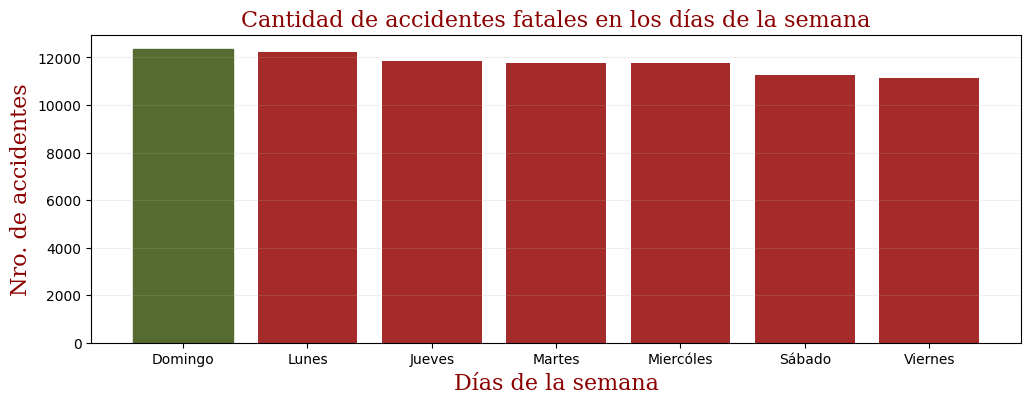

In [76]:
plt.figure(figsize = (12,4))


with plt.style.context("fast"):
    barras = plt.bar(dias_lista, suma_dias, color = "Brown")

    barras[0].set_color("DarkOliveGreen")

    plt.title("Cantidad de accidentes fatales en los días de la semana", fontdict= font)
    plt.xlabel("Días de la semana", fontdict = font)
    plt.ylabel("Nro. de accidentes", fontdict = font)
    plt.grid(axis = "y", alpha = 0.2)

plt.show()

##**Respuesta:**

En base a los gráficos presentados podemos ver que el día en el que más accidentes se presentan son los **domingos**, seguido por los **lunes**. Esto es debido, posiblemente, a que los fines de semana es cuando más la gente sale (a lugares diferentes del trabajo) y que hay más vehiculos circulando, por tanto, hay más posibilidad de que hayan accidentes fatales. Y los lunes ocurre una excepción, porque como la mayoría de los días festivos son lunes, son fechas que las personas aprovechan para salir, y pasa lo mismo que los fines de semana.

#**6. ¿Qué tipo de vehículo está involucrado con mayor frecuencia en accidentes fatales?**

Como hemos hecho anteriormente, para conocer la cantdad de accidentes por tipo de vehhículo haremos un data set propio el cual contenga la columna de "ARMAS MEDIOS" del dataframe _accidentes_.

In [77]:
tipo_vehiculo = accidentes["ARMAS MEDIOS"]
tipo_vehiculo = pd.DataFrame(tipo_vehiculo)

# tipo_vehiculo = la cantidad de accidentes por vehiculo:
tipo_vehiculo = tipo_vehiculo["ARMAS MEDIOS"].value_counts()

In [78]:
tipo_vehiculo

,count
ARMAS MEDIOS,
VEHICULO,39919
MOTO,21643
NO REPORTADO,14127
SIN EMPLEO DE ARMAS,5672
BICICLETA,629
NO REPOTADO,279
TREN,81
CONTUNDENTES,4


Como podemos ver hay una gran cantidad de accidentes cuyo tipo de vehículo no fue reportado, por lo que nos deja una gran incognita sobre el tipo de vehiculo que estuvo involucrado.  Y por otro lado, tambien tenemos ese dato repetido, por lo que intentaremos corregir eso

In [79]:
#Conseguimos la lista de indices
tipo_vehiculo_list = list(tipo_vehiculo.keys())
print(tipo_vehiculo_list)

['VEHICULO', 'MOTO', 'NO REPORTADO', 'SIN EMPLEO DE ARMAS', 'BICICLETA', 'NO REPOTADO', 'TREN', 'CONTUNDENTES']


In [80]:
#Buscamos el indice de "NO REPOTADO" y el de "NO REPORTADO"
indice_original = tipo_vehiculo_list.index("NO REPORTADO")
indice_duplicado = tipo_vehiculo_list.index("NO REPOTADO")

#Renombramos el duplicado para que en el dataframe se pueda tomar como duplicado y se elimine de manera más fácil
tipo_vehiculo_list[indice_duplicado] = tipo_vehiculo_list[indice_original]

In [81]:
#Se suman para tener el total de las veces que se usó "NO REPORTADO":
tipo_vehiculo[indice_original] += tipo_vehiculo[indice_duplicado]

<ipython-input-81-b76b1f30a745>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tipo_vehiculo[indice_original] += tipo_vehiculo[indice_duplicado]
<ipython-input-81-b76b1f30a745>:2: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  tipo_vehiculo[indice_original] += tipo_vehiculo[indice_duplicado]


In [82]:
df_vehiculos = pd.DataFrame(index = tipo_vehiculo_list, data = tipo_vehiculo)
df_vehiculos.drop_duplicates()

,count
VEHICULO,39919
MOTO,21643
NO REPORTADO,14406
SIN EMPLEO DE ARMAS,5672
BICICLETA,629
TREN,81
CONTUNDENTES,4


Una vez que ya tenemos esto corregido podremos empezar a realizar la grafica con la totalidad de los datos.

In [83]:
df_vehiculos.index

Index(['VEHICULO', 'MOTO', 'NO REPORTADO', 'SIN EMPLEO DE ARMAS', 'BICICLETA',
       'NO REPORTADO', 'TREN', 'CONTUNDENTES'],
      dtype='object')

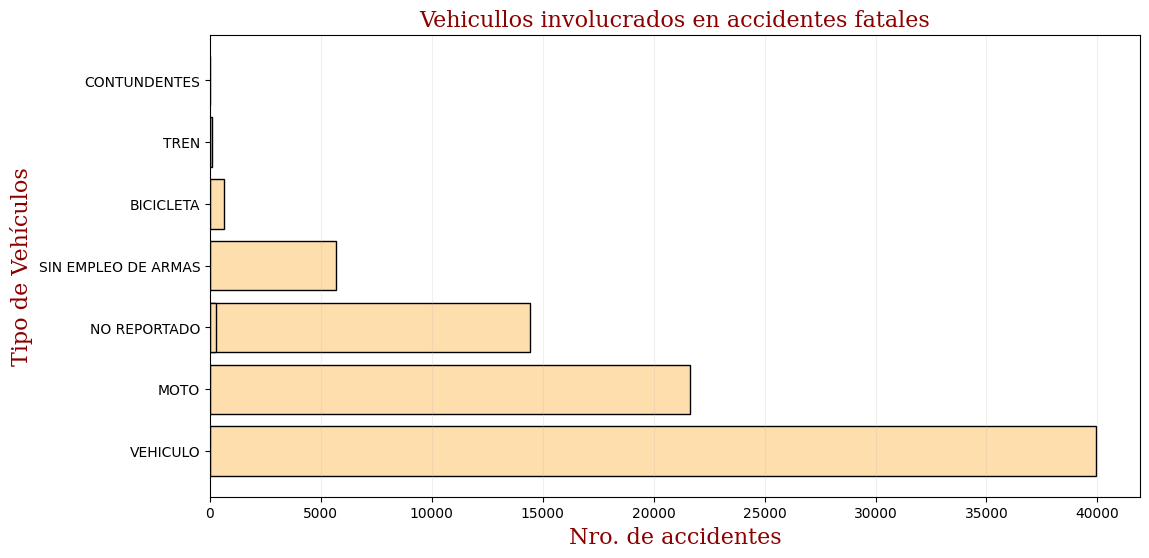

In [84]:
plt.figure(figsize = (12, 6))
with plt.style.context("fast"):
    plt.barh(df_vehiculos.index, width = tipo_vehiculo, color = "NavajoWhite", edgecolor = "black")

    plt.title("Vehicullos involucrados en accidentes fatales", fontdict = font)
    plt.xlabel("Nro. de accidentes", fontdict = font)
    plt.ylabel("Tipo de Vehículos", fontdict = font)
    plt.grid(axis = "x", alpha = 0.2)

plt.show()

## **Respuesta:**

Con todo lo anterior realizado podemos responder a la pregunta, y es que viendo las gráficos se puede decir que los más involucrados en accidentes fatales son los vehículos o carros, ya que se han visto involucrados en más de 35 mil accidentes de tránsito, lo que lo hace el tipo de vehículo más peligroso, ya que es el que cuenta con el mayor número de vicitimas, a comparación de otros.  

#**7. ¿Existe un mayor riesgo de mortalidad por accidentes de tránsito para un género en particular?**

Haciendo uso del metodo _value_counts()_ se hará el recuento de la cantidad de hombre y mujeres que han estado involucrados en accidentes de tráfico. Y en caso de requerirlo, limpieza de datos

In [85]:
#conteo de valores por género
generos_accidentes = accidentes['GENERO'].value_counts()
generos_accidentes = pd.DataFrame(generos_accidentes)
generos_accidentes

,count
GENERO,
MASCULINO,65481
FEMENINO,16709
NO REPORTADO,145
NO REPORTA,15
NO REPOTADO,4


Como podemos ver, nos salieron 3 respuestas adicionales a las de "MASCULINO" y "FEMENINO", pero notamos que son valores muy pequeños, por lo que los podemos no tomar en cuenta para las gráficas.

In [86]:
#Para mejor entendimiento de los datos en las gráficas se eliminan las filas que no correspondan al género de las personas
generos_accidentes.drop(index = ["NO REPORTADO", "NO REPORTA", "NO REPOTADO"], axis= 0, inplace = True)

In [91]:
generos_accidentes.reset_index(inplace = True)
generos_accidentes.rename(columns = {"index": "GENERO"}, inplace = True)
generos_accidentes

,GENERO,count
0,MASCULINO,65481
1,FEMENINO,16709


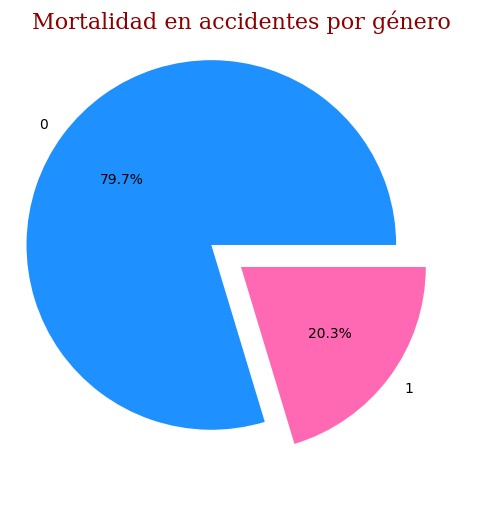

In [96]:
plt.figure (figsize = (12, 6))

plt.pie(generos_accidentes["count"], labels= generos_accidentes.index, colors = ["DodgerBlue", "HotPink"], autopct = "%.1f%%", explode = [0.2, 0])

plt.title("Mortalidad en accidentes por género", fontdict = font)

plt.show()

##**Respuesta:**

Por lo visto en estos datos se puede ver claramente que los hombres son los que más pierden la vida en estos accidentes, por lo que es correcto afirmar que los hombres tienen un mayor riesgo de mortalidad

# **8. ¿Varía este riesgo según el tipo de vehiculo o la zona del accidente?**

##**Respuesta:**

Basandonos en las gráficas anteriores que nos hablan de lo municipios y del tipo de vehiculos es fácil intuir que si la gran mayoría de accidentes ocurren en un carro y en las ciudades capitales del país, podemos decir que es muy probable que sí haya variación del riesgo según la zona, porque en los municipios más pequeños donde no hay tanto flujo de vehiculos es menos probable que ocurra un accidente precisamente por eso, por la cantidad de vehiculos de la zona

#**9. ¿En qué grupos de edad se observa la mayor incidencia de víctimas fatales?**

Usando la misma metodología que el punto 7 vamos a respnder esta pregunta, puesto que calcularemos la cantidad de veces que un grupo de edad ha sido victima de un accidente y con estos datos procederemos a grraficarlos.

In [97]:
grupos_edad = accidentes['GRUPO ETARÍO'].value_counts()
grupos_edad = pd.DataFrame(grupos_edad)
grupos_edad

,count
GRUPO ETARÍO,
ADULTOS,75713
ADOLESCENTES,3825
MENORES,2667
NO REPORTADO,145
NO REPOTADO,4


In [98]:
#Para representar de mejor manera las gráficas, se eliminan las filas que no correspondan al un grupo de edad
grupos_edad.drop(index = ["NO REPORTADO","NO REPOTADO"], axis= 0, inplace = True)

In [103]:
grupos_edad.reset_index(inplace = True)
grupos_edad.rename(columns = {"index": "GRUPO ETARÍO"}, inplace = True)
grupos_edad

,GRUPO ETARÍO,count
0,ADULTOS,75713
1,ADOLESCENTES,3825
2,MENORES,2667


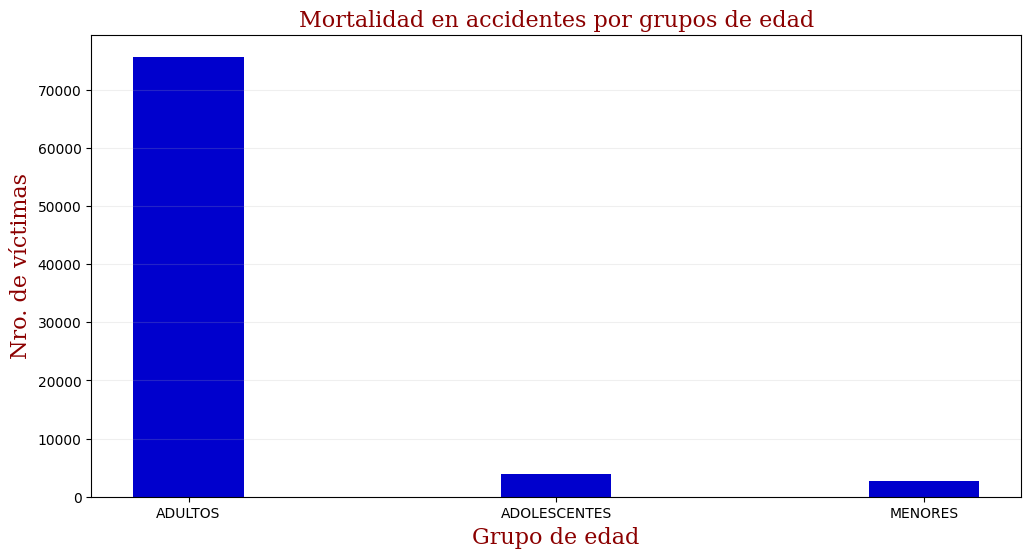

In [106]:
plt.figure (figsize = (12, 6))

with plt.style.context("fast"):
    plt.bar(grupos_edad["GRUPO ETARÍO"], grupos_edad['count'], width = 0.3, color = "MediumBlue")

    plt.title("Mortalidad en accidentes por grupos de edad", fontdict = font)
    plt.xlabel("Grupo de edad", fontdict = font)
    plt.ylabel("Nro. de víctimas", fontdict = font)
    plt.grid(axis = "y", alpha = 0.2)

plt.show()

##**Respuesta:**

Los datos nos dicen que hay tres tipos de grupos de edad: adultos, adolescentes y menores. Y gráficando en su totalidad la cantidad de accidentes que han ocurrido se puede ver que son los **adultos** son las mayores víctimas en los accidentes de tránsito. Lo cual tiene sentido, porque son mayormente los adultos quienes conducen, a comparación de los otros grupos de edad.

#**10. ¿Cuál es el riesgo comparativo de sufrir un accidente fatal en diferentes tipos de vehículos?**

Haciendo uso del método _groupby()_ haremos el cálculo de cuantos muertos y victimas han habido según el tipo de vehículo en el que se presentó el accidente. Seguidamente quitaremos los datos que no nos dan datos interesantes. Y luego graficaremos para observar los datos agrupados.

In [107]:
vehiculos_accidentes = accidentes.groupby("ARMAS MEDIOS")["CANTIDAD"].sum().sort_values(ascending = False)
vehiculos_accidentes

,CANTIDAD
ARMAS MEDIOS,
VEHICULO,44564.0
MOTO,23216.0
NO REPORTADO,16168.0
SIN EMPLEO DE ARMAS,6413.0
BICICLETA,649.0
NO REPOTADO,318.0
TREN,87.0
CONTUNDENTES,4.0


In [108]:
vehiculos_accidentes.drop(["NO REPOTADO", "NO REPORTADO"], axis = 0, inplace = True)

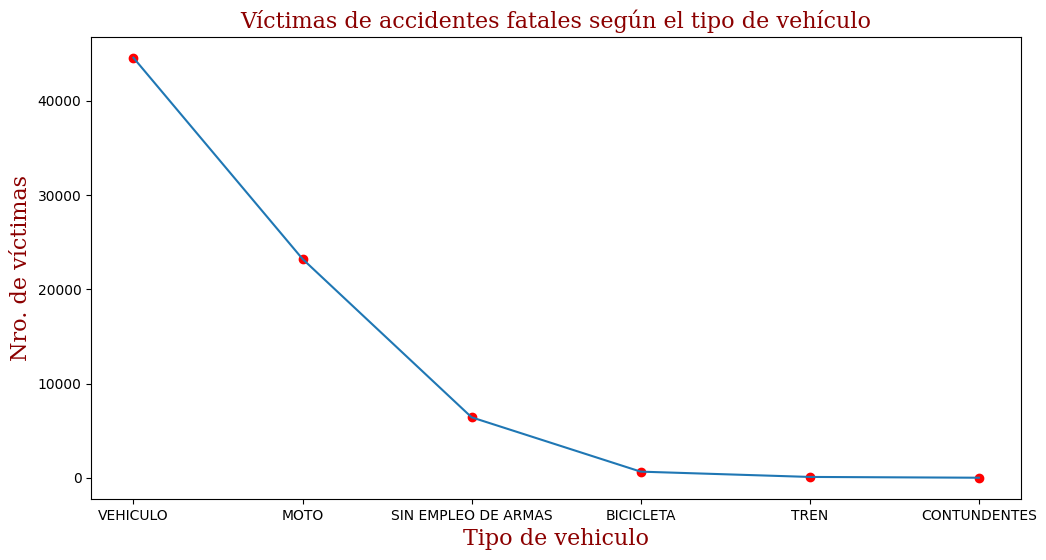

In [109]:
plt.figure(figsize= (12,6))

plt.plot(vehiculos_accidentes)
plt.scatter(vehiculos_accidentes.index, vehiculos_accidentes, color = "Red")

plt.title("Víctimas de accidentes fatales según el tipo de vehículo", fontdict = font)
plt.xlabel("Tipo de vehiculo", fontdict = font)
plt.ylabel("Nro. de víctimas", fontdict = font)

plt.show()

##**Respuesta:**

Como podemos ver, los **carros** son el tipo de vehículo donde más víctimas han habido, y seguido por la moto.
Si observamos en nuestro entorno y nuestra realidad podremos ver que en Colombia los vehículos que más se observan son los carros, ya que son los que abundan en las calles y por más que se vean muchas motos en las calles no representan una gran mayoría frente a la cantidad de carros que puede haber. Por esto mismo es que tiene sentido que sean los carros quienes tengan más víctimas en accidentes, porque es el tipo de vehículos que más se usa en Colombia.

Así que en comparación con otro tipo de vehiculos el riesgo de sufrir un accidente fatal en un carro es mucho mayor que los demás, y con bastante diferencia, ya que tienen casi el doble que las motos.